# 02 · Queue anatomy — T0, T2, T3, and the discharge rate μ

The queue object is the atom of this platform. For one sensor on one day:

- **T0** — queue onset: speed falls through v_c (speed at capacity)
- **T2** — the worst point (minimum speed v_t2)
- **T3** — recovery: speed returns above v_c
- **P = T3 − T0** — congestion duration (hours)
- **μ** — the *discharge rate*: median flow while the queue drains.
  μ/C < 1 is the **capacity drop** — an active bottleneck serves *less*
  than its own capacity once the queue forms (empirically μ/C ≈ 0.85–0.92; Cassidy & Bertini 1999 measured ~8–15% drops).

Why V/C cannot see any of this: V/C is one number per hour;
the queue is a *process*. See
[THEORY_FOUNDATIONS](../docs/teaching/THEORY_FOUNDATIONS.md).

In [1]:
%matplotlib inline
# If cbi-plus is pip-installed this import just works; on a raw repo
# checkout we add the repo root to the path instead.
try:
    import cbi_pipeline
except ImportError:
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent))
from cbi_pipeline import api
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["figure.dpi"] = 90
print("cbi-plus", api.version())

cbi-plus 2.2.0


In [2]:
df = api.simulate_corridor(days=1, seed=3)
one = df[(df["sensor_uid"] == "SIM03")].sort_values("datetime").reset_index(drop=True)
speed = one["speed_mph"].to_numpy()
flow = one["flow_vph"].to_numpy()
V_C = 50.0   # speed at capacity for this corridor
cl = api.classify_day(speed, flow, v_c_mph=V_C)
{k: (round(v, 2) if isinstance(v, float) else v) for k, v in cl.items()}

   [stage2] detector: packaged detector (NaN-gap guard + 2-bin persistence active)


{'t0_index': 79,
 't2_index': 110,
 't3_index': 129,
 'P_min': 255.0,
 'min_speed_mph': 17.35,
 'v_c_mph': 50.0,
 'demand_veh': 7441.67,
 'regime': 'severe',
 'method': 'SBM',
 'avg_discharge_rate': 1750.98}

`classify_day` found the queue. Now draw what it found.

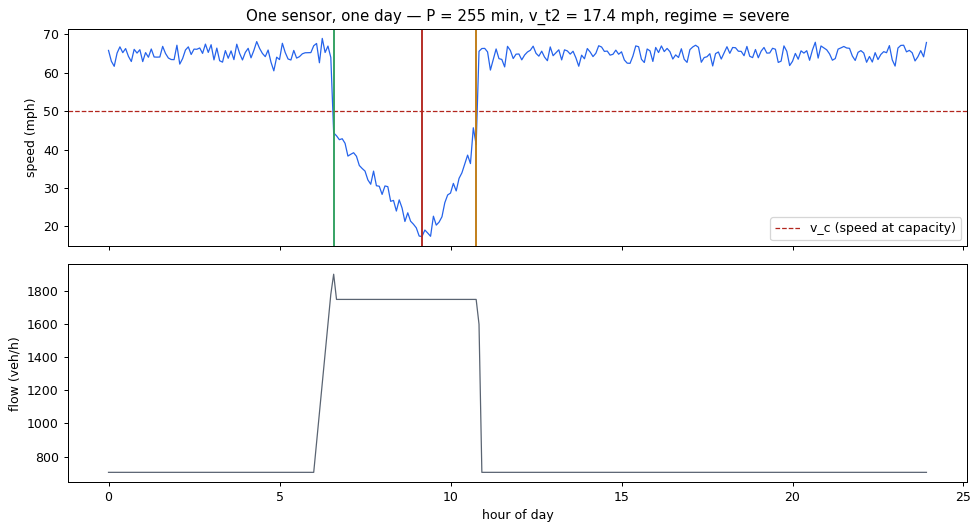

In [3]:
t = np.arange(len(speed)) * 5 / 60          # hours
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(t, speed, lw=1, color="#2563eb")
ax[0].axhline(V_C, color="#b3261e", ls="--", lw=1, label="v_c (speed at capacity)")
for name, idx, col in [("T0", cl["t0_index"], "#2f9e5e"),
                       ("T2", cl["t2_index"], "#b3261e"),
                       ("T3", cl["t3_index"], "#c07a12")]:
    if idx is not None and not (isinstance(idx, float) and np.isnan(idx)):
        ax[0].axvline(t[int(idx)], color=col, lw=1.5)
        ax[0].annotate(name, (t[int(idx)], 72), color=col, ha="center", fontweight="bold")
ax[0].set_ylabel("speed (mph)"); ax[0].legend(loc="lower right")
ax[0].set_title(f"One sensor, one day — P = {cl['P_min']:.0f} min, v_t2 = {cl['min_speed_mph']:.1f} mph, regime = {cl['regime']}")
ax[1].plot(t, flow, lw=1, color="#5a6472")
ax[1].set_ylabel("flow (veh/h)"); ax[1].set_xlabel("hour of day")
plt.tight_layout(); plt.show()

## The discharge window and μ

While the queue discharges (T2 → T3), the bottleneck serves its *actual*
throughput. The median flow in that window is **μ** — the number a ramp
meter, a signal plan, or a capacity analysis should actually use.

In [4]:
dw = api.discharge_window(speed, flow, cl["t0_index"], cl["t2_index"], cl["t3_index"], v_c_mph=V_C)
start, end = dw                                    # (start_idx, end_idx) tuple
mu_vphpl = float(np.median(flow[start:end + 1]))   # flow_vph is PER LANE
C_vphpl = 1900.0                                   # the simulator's capacity
print(f"discharge window: bins {start}..{end} ({(end-start+1)*5} min)")
print(f"mu = {mu_vphpl:.0f} veh/h/ln   mu/C = {mu_vphpl / C_vphpl:.3f}")


discharge window: bins 111..129 (95 min)
mu = 1748 veh/h/ln   mu/C = 0.920


**Read the flow panel again with mu in hand**: before T0 the flow climbs
to ~C (the pre-breakdown peak); the moment the queue forms it DROPS to mu
and stays there while the queue drains — that gap *is* the capacity drop.
Empirically the drop is ~8–15% (Cassidy & Bertini 1999), i.e. mu/C ≈
0.85–0.92; our simulator plants 0.92.

### Exercises
1. Re-run with `seed=5` — do T0/T2/T3 move? Why does day-to-day variation matter for planning?
2. Hand-check: open `docs/teaching/QVDF_Teaching_V2.xlsx` and find T0/T2/T3
   for the same shape with pencil-and-Excel logic.
3. In the flow panel, can you *see* the capacity drop while the queue drains?